# ML Learning Based Expert System - Naive Bayesian - Classification

In [27]:
import pandas as pd
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Categorical mappings
temperature_mapping = {'Hot': 0, 'Mild': 1, 'Cool': 2}
humidity_mapping = {'High': 0, 'Low': 1}
wind_mapping = {'Weak': 0, 'Strong': 1}
playgolf_mapping = {'No': 0, 'Yes': 1}

# Data mapping
data = {
    'Temperature': [temperature_mapping[val] for val in ['Hot', 'Hot', 'Hot', 'Mild', 'Mild', 'Mild', 'Cool', 'Cool', 'Cool']],
    'Humidity': [humidity_mapping[val] for val in ['High', 'High', 'Low', 'High', 'Low', 'Low', 'High', 'Low', 'Low']],
    'Wind': [wind_mapping[val] for val in ['Weak', 'Strong', 'Weak', 'Weak', 'Weak', 'Strong', 'Strong', 'Weak', 'Strong']],
    'PlayGolf': [playgolf_mapping[val] for val in ['No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No']]
}

# Define the Bayesian Network structure
model = BayesianNetwork([
    ('PlayGolf','Temperature'),
    ('PlayGolf','Humidity'),
    ('PlayGolf','Wind')
])

cpd_playgolf = TabularCPD(variable='PlayGolf', variable_card=2, 
                          values=[[0.4], [0.6]])  

cpd_temperature = TabularCPD(variable='Temperature', variable_card=3, 
                              values=[[0.5, 0.4], 
                                      [0.3, 0.4], 
                                      [0.2, 0.2]], 
                              evidence=['PlayGolf'], evidence_card=[2])

cpd_humidity = TabularCPD(variable='Humidity', variable_card=2, 
                          values=[[0.6, 0.3], 
                                  [0.4, 0.7]], 
                          evidence=['PlayGolf'], evidence_card=[2])

cpd_wind = TabularCPD(variable='Wind', variable_card=2, 
                      values=[[0.7, 0.4], 
                              [0.3, 0.6]], 
                      evidence=['PlayGolf'], evidence_card=[2])

# Add CPDs to the model
model.add_cpds(cpd_playgolf, cpd_temperature, cpd_humidity, cpd_wind)

# Validate the model
assert model.check_model()

# Initialize inference engine
inference = VariableElimination(model)

# Perform forward inference
query_playgolf = inference.query(
    variables=['PlayGolf'], 
    evidence={'Temperature': 0, 'Humidity': 0, 'Wind': 0}  # Example: Temperature=Hot, Humidity=High, Wind=Weak
)

# Query: Probability of Temperature, Humidity, Wind given PlayGolf = Yes
query_temperature = inference.query(variables=['Temperature'], evidence={'PlayGolf': 1})
query_humidity = inference.query(variables=['Humidity'], evidence={'PlayGolf': 1})
query_wind = inference.query(variables=['Wind'], evidence={'PlayGolf': 1})

# Output the results
print("\nProbability distribution for PlayGolf given Temperature=Hot, Humidity=High, Wind=Weak:")
print(query_playgolf)

print("\nProbability distribution for Temperature given PlayGolf = Yes:")
print(query_temperature)

print("\nProbability distribution for Humidity given PlayGolf = Yes:")
print(query_humidity)

print("\nProbability distribution for Wind given PlayGolf = Yes:")
print(query_wind)



Probability distribution for PlayGolf given Temperature=Hot, Humidity=High, Wind=Weak:
+-------------+-----------------+
| PlayGolf    |   phi(PlayGolf) |
+=============+=================+
| PlayGolf(0) |          0.7447 |
+-------------+-----------------+
| PlayGolf(1) |          0.2553 |
+-------------+-----------------+

Probability distribution for Temperature given PlayGolf = Yes:
+----------------+--------------------+
| Temperature    |   phi(Temperature) |
+================+====================+
| Temperature(0) |             0.4000 |
+----------------+--------------------+
| Temperature(1) |             0.4000 |
+----------------+--------------------+
| Temperature(2) |             0.2000 |
+----------------+--------------------+

Probability distribution for Humidity given PlayGolf = Yes:
+-------------+-----------------+
| Humidity    |   phi(Humidity) |
+=============+=================+
| Humidity(0) |          0.3000 |
+-------------+-----------------+
| Humidity(1) |    

In [5]:
# Reason being it is called Naive because it consider all the features as 
# conditionally independent of each other given the target variable

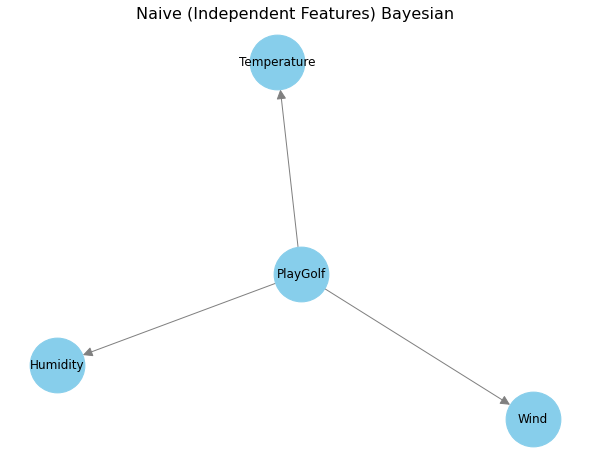

In [28]:
import matplotlib.pyplot as plt
import networkx as nx

# Create DAG
graph = nx.DiGraph()  
graph.add_edges_from(model.edges())  

# Plot the graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph)  
nx.draw(
    graph, pos,
    with_labels=True,
    node_size=3000,
    node_color='skyblue',
    font_size=12,
    font_color='black',
    arrowsize=20,
    edge_color='gray'
)
plt.title("Naive (Independent Features) Bayesian", fontsize=16)
plt.show()


# Bag-of-words Naïve Bayes

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

dataset = [
    "won 1 million", 
    "won $99", 
    "expert system course $99", 
    "Don't forget the expert system project deadline"
]
labels = ["Spam", "Spam", "Ham", "Ham"]

# Convert text to feature vectors in bag-of-words representation
cv = CountVectorizer()
X = cv.fit_transform(dataset)

pd.DataFrame(X.toarray(), columns=cv.get_feature_names_out())


,99,course,deadline,don,expert,forget,million,project,system,the,won
0,0,0,0,0,0,0,1,0,0,0,1
1,1,0,0,0,0,0,0,0,0,0,1
2,1,1,0,0,1,0,0,0,1,0,0
3,0,0,1,1,1,1,0,1,1,1,0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.5, random_state=80)

# Train a Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Test with a new input
new_input = ["expert system course $99"]
new_X = cv.transform(new_input)
predictions = model.predict(new_X)

for inp, label in zip(new_input, predictions):
    print(f"Input: '{inp}' is classified as: {label}")

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

         Ham       1.00      1.00      1.00         1
        Spam       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Input: 'expert system course $99' is classified as: Ham
